# TinyStories — Generation Playground

In [1]:
import torch
import pickle
import os
import glob
from cs336_basics.bpe import train_bpe
from cs336_basics.tokenizer import Tokenizer
from cs336_basics.model import TransformerLM

DEVICE = 'mps' if torch.mps.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: mps


## 1. Load tokenizer (trains BPE once, then caches)

In [2]:
TOKENIZER_CACHE = 'data/tokenizer_cache.pkl'
VOCAB_SIZE = 10000
SPECIAL_TOKENS = ['<|endoftext|>']

if os.path.exists(TOKENIZER_CACHE):
    print('Loading tokenizer from cache...')
    with open(TOKENIZER_CACHE, 'rb') as f:
        vocab, merges = pickle.load(f)
else:
    print('Training BPE (this takes a few minutes)...')
    vocab, merges = train_bpe('data/TinyStoriesV2-GPT4-train.txt', VOCAB_SIZE, SPECIAL_TOKENS)
    with open(TOKENIZER_CACHE, 'wb') as f:
        pickle.dump((vocab, merges), f)
    print('Saved to cache.')

tokenizer = Tokenizer(vocab, merges, SPECIAL_TOKENS)
EOT_ID = tokenizer.encode(SPECIAL_TOKENS[0])[0]
print(f'Vocab size: {len(vocab)}, EOT token id: {EOT_ID}')

Loading tokenizer from cache...
Vocab size: 10000, EOT token id: 256


## 2. Load model checkpoint

In [3]:
# Auto-picks latest checkpoint — change path to use a specific one
checkpoints = sorted(glob.glob('checkpoints/ckpt_step_*.pt'))
CHECKPOINT = checkpoints[-1]
print(f'Loading: {CHECKPOINT}')

model = TransformerLM(
    vocab_size=10000,
    context_length=256,
    num_layers=4,
    d_model=512,
    num_heads=16,
    d_ff=1344,
    device=DEVICE,
)

ckpt = torch.load(CHECKPOINT, map_location=DEVICE)
model.load_state_dict(ckpt['model'])
model.eval()
print(f'Loaded step {ckpt["iteration"]} | params: {sum(p.numel() for p in model.parameters()):,}')

Loading: checkpoints/ckpt_step_4000.pt
Loaded step 4000 | params: 22,696,448


## 3. Generate

In [4]:
@torch.no_grad()
def generate_with(model_, prompt: str, max_new_tokens: int = 200, temperature: float = 0.8, top_p: float = 0.9) -> str:
    ids = tokenizer.encode(prompt)
    tokens = torch.tensor(ids, dtype=torch.long, device=DEVICE).unsqueeze(0)

    for _ in range(max_new_tokens):
        ctx = tokens[:, -256:]
        positions = torch.arange(ctx.shape[1], device=DEVICE).unsqueeze(0)
        logits = model_(ctx, positions)[:, -1, :]

        logits = logits / temperature
        probs = torch.softmax(logits, dim=-1)

        sorted_probs, sorted_idx = torch.sort(probs, descending=True)
        cumprobs = sorted_probs.cumsum(dim=-1)
        mask = cumprobs - sorted_probs > top_p
        sorted_probs[mask] = 0
        sorted_probs /= sorted_probs.sum()
        next_id = sorted_idx[0, torch.multinomial(sorted_probs[0], 1)]  # shape (1,)

        if next_id.item() == EOT_ID:
            break
        tokens = torch.cat([tokens, next_id.unsqueeze(0)], dim=1)

    return tokenizer.decode(tokens[0].tolist())


def generate(prompt: str, max_new_tokens: int = 200, temperature: float = 0.8, top_p: float = 0.9) -> str:
    return generate_with(model, prompt, max_new_tokens, temperature, top_p)

In [5]:
prompt = 'Once upon a time there was a little girl named Lily'
print(generate(prompt, max_new_tokens=200, temperature=0.8, top_p=0.9))

Once upon a time there was a little girl named Lily. She loved to dress up in pretty clothes and play with her friends. One day, Lily went to the park with her mom. She saw a big box with a nice dress inside. Lily wanted to play with the dress, but she was too small to play with it.
Lily's mom said, "Let's have a party!" Lily was very excited and started to shout, "Yes, let's go!" They played and had a lot of fun. Lily had so much fun! She learned that when she grew up, she could make friends and be happy.
As they played, Lily's friend Tim came over to play. She said, "Lily, let's wrap the dress together!" Tim looked at Lily and said, "Yes, let's do it!" They laughed and had lots of fun. When they were done, they went home and had a nice bath. Lily's mom was proud of her for being a great help


In [6]:
# Try different prompts / settings
prompt = 'Tom and his dog'
print(generate(prompt, max_new_tokens=150, temperature=1.0, top_p=0.95))

Tom and his dog, Max, came up with a thief. Max was bitter now because he wanted a big dog like the other dogs. He saw Tom and his toy fall. The other kids could not find the toy. Tom was very sad.
Tom went to Max and said, "I'm sorry, Max. We can't play with him. We can still be friends." Max looked at the toy fur and saw that the toy was not there either. Tom learned that not all plays in the future was not as important as friends. And they all played happily in the fall box.



## 4. Checkpoint comparison — same prompt, same seed, every checkpoint

How does generation quality change as training progresses? We feed the same prompt with the same seed through each saved checkpoint (step 1k → 4k) and print the outputs side by side. We also score a fixed reference string with each checkpoint to see validation-style NLL drop monotonically.

In [7]:
def load_checkpoint(path: str) -> TransformerLM:
    m = TransformerLM(
        vocab_size=10000,
        context_length=256,
        num_layers=4,
        d_model=512,
        num_heads=16,
        d_ff=1344,
        device=DEVICE,
    )
    state = torch.load(path, map_location=DEVICE)
    m.load_state_dict(state['model'])
    m.eval()
    return m


SEED = 1234
COMPARE_PROMPT = 'Once upon a time there was a little girl named Lily'

for path in sorted(glob.glob('checkpoints/ckpt_step_*.pt')):
    m = load_checkpoint(path)
    torch.manual_seed(SEED)
    out = generate_with(m, COMPARE_PROMPT, max_new_tokens=120, temperature=0.8, top_p=0.9)
    step = path.split('_step_')[1].split('.pt')[0]
    print(f'=== step {step} ===')
    print(out)
    print()
    del m

=== step 1000 ===
Once upon a time there was a little girl named Lily. She loved to play with her toy cars in the garden. One day, she was going to get some wheat and put on her shoes. She put the blanket in her trunk and went to her room.
Lily saw her friend, Tom, who was sitting on a bridge. She said, "Wow, that's a pretty perfect sour fruits!" Tom smiled and said, "Yes, I would love to draw on the sofa with your presses."
The next day,

=== step 2000 ===
Once upon a time there was a little girl named Lily. She loved to play outside with her friends. One day, she found a big basket and wanted to mark it.
Lily went to her mom and asked, "Mom, can I play with the basketball?" Her mom said, "Yes, let's look!" So, Lily put the basketball in the market.
They mixed the basketball together, and soon the basketball was full of juicy basketballs.

=== step 3000 ===
Once upon a time there was a little girl named Lily. She loved to play in her backyard. One day, she found a big pool of jelly in

In [8]:
@torch.no_grad()
def avg_nll(model_, text: str) -> float:
    ids = tokenizer.encode(text)
    tokens = torch.tensor(ids, dtype=torch.long, device=DEVICE).unsqueeze(0)
    positions = torch.arange(tokens.shape[1], device=DEVICE).unsqueeze(0)
    logits = model_(tokens, positions)
    log_probs = torch.log_softmax(logits[:, :-1, :], dim=-1)
    targets = tokens[:, 1:]
    nll = -log_probs.gather(-1, targets.unsqueeze(-1)).squeeze(-1)
    return nll.mean().item()


REFERENCE = (
    'Once upon a time there was a little girl named Lily. She loved to play '
    'in the park with her dog. One sunny day, she saw a big red ball.'
)

print(f'Reference: {REFERENCE!r}')
print()
print(f"{'checkpoint':<28} {'avg NLL':>10}")
for path in sorted(glob.glob('checkpoints/ckpt_step_*.pt')):
    m = load_checkpoint(path)
    nll = avg_nll(m, REFERENCE)
    print(f'{path:<28} {nll:>10.4f}')
    del m

Reference: 'Once upon a time there was a little girl named Lily. She loved to play in the park with her dog. One sunny day, she saw a big red ball.'

checkpoint                      avg NLL
checkpoints/ckpt_step_1000.pt     1.0653
checkpoints/ckpt_step_2000.pt     0.9725
checkpoints/ckpt_step_3000.pt     1.0325
checkpoints/ckpt_step_4000.pt     1.0359


## 5. Sampling sweep — temperature × top-p on the final model

Same prompt, same seed, varying decoding params. Lower temperature/top_p → safer, repetitive. Higher → more diverse, more chaotic.

In [9]:
SWEEP_PROMPT = 'One day, a small dragon found a key in the forest.'
TEMPERATURES = [0.3, 0.7, 1.0, 1.3]
TOP_PS = [0.5, 0.9, 1.0]

for t in TEMPERATURES:
    for p in TOP_PS:
        torch.manual_seed(SEED)
        out = generate_with(model, SWEEP_PROMPT, max_new_tokens=80, temperature=t, top_p=p)
        snippet = out[len(SWEEP_PROMPT):].strip().replace('\n', ' ')
        print(f'--- T={t} top_p={p} ---')
        print(snippet[:300])
        print()

--- T=0.3 top_p=0.5 ---
The dragon was very curious and wanted to see what was inside. He opened the door and saw a big, friendly dragon. The dragon was very friendly and liked to play with the dragon. The dragon said to the dragon, "I want to play with you, dragon. I want to play with you." The

--- T=0.3 top_p=0.9 ---
The dragon was very happy and wanted to find the key. The dragon asked the dragon, "Can you help me find my key?" The dragon said, "Yes, I can help you." The dragon was very happy. He found a big box and used it to open the box. The dragon was very happy and thanked

--- T=0.3 top_p=1.0 ---
The dragon was very happy and wanted to find the key. The dragon asked the dragon to help him. The dragon said, "I will help you find your home." The dragon was very happy. He found a big tree and used it to lift the dragon's home. The dragon was very happy to be home

--- T=0.7 top_p=0.5 ---
The dragon was very happy and wanted to find the key. The dragon asked the dragon, "Can you 

In [10]:
# Sanity check: T → 0 ≈ argmax. Two runs with different seeds should be (almost) identical.
for s in [0, 999]:
    torch.manual_seed(s)
    out = generate_with(model, SWEEP_PROMPT, max_new_tokens=40, temperature=0.01, top_p=1.0)
    print(f'seed={s}: {out}')
    print()

seed=0: One day, a small dragon found a key in the forest. The dragon was very curious and wanted to see what was inside. He tried to open the key, but it was too hard.
The dragon tried to open the key

seed=999: One day, a small dragon found a key in the forest. The dragon was very curious and wanted to see what was inside. He tried to open the key, but it was too hard.
The dragon tried to open the key



## 6. Attention visualization

The model uses `F.scaled_dot_product_attention` (fused, no exposed weights). To visualize attention we re-run the forward pass here, replacing the fused call with a manual `softmax(QKᵀ/√d)` so we can capture the per-head probability matrices. We reuse the trained `W_q/W_k/W_v/W_o` and the existing `rope` module — no new parameters, no edits to `model.py`.

In [11]:
import math

@torch.no_grad()
def attn_with_weights(attn_module, x, token_positions):
    b, s, _ = x.shape
    h, d_k = attn_module.num_heads, attn_module.d_k

    q = attn_module.W_q(x).view(b, s, h, d_k).transpose(1, 2)
    k = attn_module.W_k(x).view(b, s, h, d_k).transpose(1, 2)
    v = attn_module.W_v(x).view(b, s, h, d_k).transpose(1, 2)

    q = attn_module.rope(q, token_positions)
    k = attn_module.rope(k, token_positions)

    scores = (q @ k.transpose(-2, -1)) / math.sqrt(d_k)
    causal = torch.ones(s, s, dtype=torch.bool, device=x.device).tril()
    scores = scores.masked_fill(~causal, float('-inf'))
    probs = torch.softmax(scores, dim=-1)

    out = (probs @ v).transpose(1, 2).contiguous().view(b, s, -1)
    return attn_module.W_o(out), probs


@torch.no_grad()
def forward_with_attn(model_, token_ids):
    positions = torch.arange(token_ids.shape[1], device=token_ids.device).unsqueeze(0)
    x = model_.embedding(token_ids)
    all_attn = []
    for block in model_.blocks:
        x_norm = block.attention_rms_norm(x)
        attn_out, probs = attn_with_weights(block.attention, x_norm, positions)
        x = x + attn_out
        x_norm = block.ffn_rms_norm(x)
        x = x + block.ffn(x_norm)
        all_attn.append(probs[0])  # drop batch dim → [heads, seq, seq]
    x = model_.rms_norm(x)
    logits = model_.output_linear(x)
    return logits, all_attn

seq len: 15, layers: 4, heads: 16
tokens: ['Lily', ' and', ' her', ' dog', ' ran', ' to', ' the', ' park', ' to', ' play', ' with', ' the', ' red', ' ball', '.']


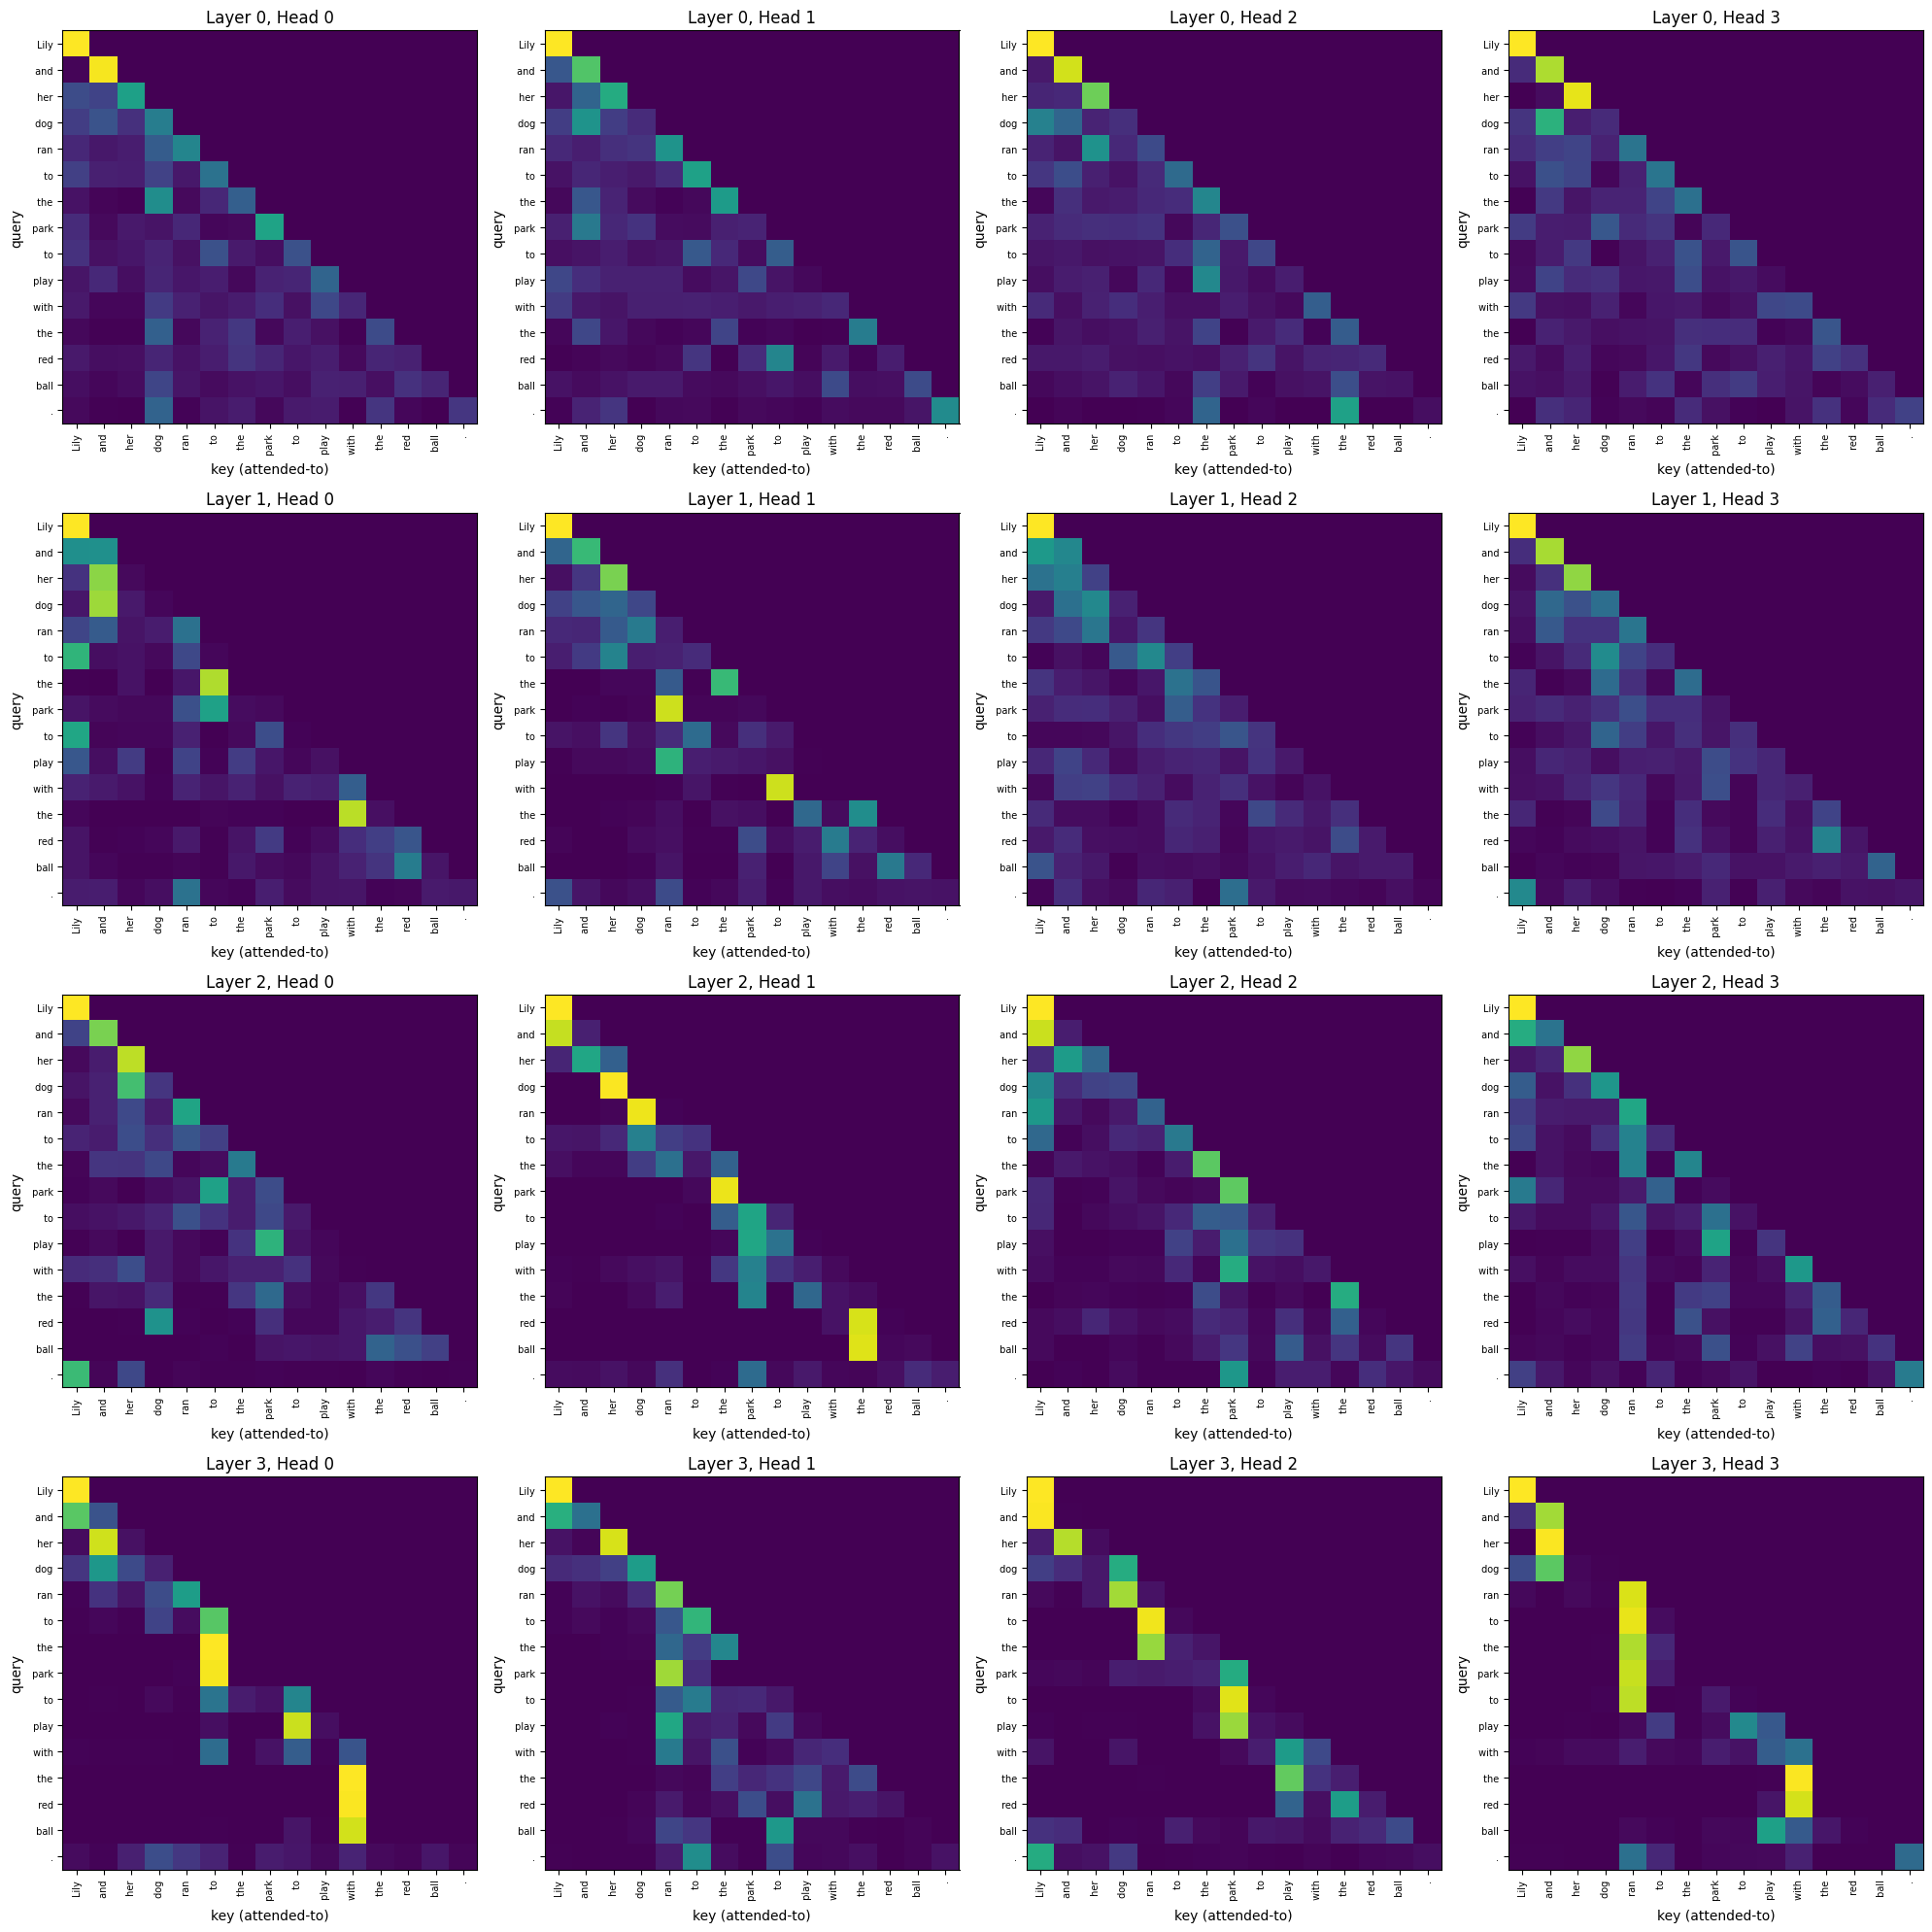

In [12]:
import matplotlib.pyplot as plt

ATTN_PROMPT = 'Lily and her dog ran to the park to play with the red ball.'
ids = tokenizer.encode(ATTN_PROMPT)
token_labels = [tokenizer.vocab[i].decode('utf-8', errors='replace') for i in ids]
tokens = torch.tensor(ids, dtype=torch.long, device=DEVICE).unsqueeze(0)

logits, attn = forward_with_attn(model, tokens)
print(f'seq len: {tokens.shape[1]}, layers: {len(attn)}, heads: {attn[0].shape[0]}')
print('tokens:', token_labels)


def plot_attention(probs, labels, layer, head, ax=None):
    a = probs.float().cpu().numpy()
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(a, cmap='viridis', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel('key (attended-to)')
    ax.set_ylabel('query')
    ax.set_title(f'Layer {layer}, Head {head}')


# Grid: all 4 layers × first 4 heads (16 plots is dense; show a slice)
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
for L in range(4):
    for H in range(4):
        plot_attention(attn[L][H], token_labels, L, H, ax=axes[L, H])
plt.tight_layout()
plt.show()

In [13]:
# Sanity checks: rows sum to 1, upper triangle is zero (causal mask).
for L, a in enumerate(attn):
    row_sums = a.sum(dim=-1)
    upper = a.triu(1).abs().max()
    print(f'layer {L}: row-sum min={row_sums.min().item():.6f} max={row_sums.max().item():.6f} | upper-tri max={upper.item():.2e}')

# Also verify our manual forward agrees with the fused one on logits.
with torch.no_grad():
    positions = torch.arange(tokens.shape[1], device=DEVICE).unsqueeze(0)
    fused_logits = model(tokens, positions)
diff = (logits - fused_logits).abs().max().item()
print(f'manual vs fused logits max-abs diff: {diff:.2e}')

layer 0: row-sum min=1.000000 max=1.000000 | upper-tri max=0.00e+00
layer 1: row-sum min=1.000000 max=1.000000 | upper-tri max=0.00e+00
layer 2: row-sum min=1.000000 max=1.000000 | upper-tri max=0.00e+00
layer 3: row-sum min=1.000000 max=1.000000 | upper-tri max=0.00e+00
manual vs fused logits max-abs diff: 2.00e-05
